<a href="https://colab.research.google.com/github/everjava/sctech/blob/main/Semana_2_Pipeline_de_ML_%2B_Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
import seaborn as sns  # Biblioteca de visualização que possui datasets de estudo embutidos

In [ ]:
df = sns.load_dataset('tips')

In [ ]:
print("--- separção de features e target ---")
# Vamos usar o dataset de 'tips' (gorjetas) que já está na memória do Colab (df)
# Separando as features numéricas
X_estudo = df[['total_bill', 'size']]
y_estudo = df['tip']

--- separção de features e target ---


In [ ]:
# O comando train_test_split faz a divisão automaticamente!
# test_size=0.20 significa que 20% vai para a prova (Teste)
X_treino, X_teste, y_treino, y_teste = train_test_split(X_estudo, y_estudo, test_size=0.20, random_state=42)

print(f"Total de registros na tabela original: {len(df)}")
print(f"Dados para a IA ESTUDAR (Treino): {len(X_treino)}")
print(f"Dados escondidos para a PROVA (Teste): {len(X_teste)}")

Total de registros na tabela original: 244
Dados para a IA ESTUDAR (Treino): 195
Dados escondidos para a PROVA (Teste): 49


In [ ]:
print("\n--- 2. SIMULANDO O VILÃO: OVERFITTING NA PRÁTICA ---")
# Vamos criar uma linha com alguns "erros/ruídos" de propósito
rng = np.random.RandomState(1)
X_onda = np.sort(5 * rng.rand(80, 1), axis=0)
y_onda = np.sin(X_onda).ravel()
y_onda[::5] += 3 * (0.5 - rng.rand(16)) # Adicionando a "sujeira"


--- 2. SIMULANDO O VILÃO: OVERFITTING NA PRÁTICA ---


In [ ]:
# IA 1: O Aluno Bom (Aprende a tendência)
modelo_ideal = DecisionTreeRegressor(max_depth=3)
modelo_ideal.fit(X_onda, y_onda)

# IA 2: O Aluno Decoreba (Fica viciado na sujeira)
modelo_decoreba = DecisionTreeRegressor(max_depth=15) # Muito profundo
modelo_decoreba.fit(X_onda, y_onda)

DecisionTreeRegressor(max_depth=15)

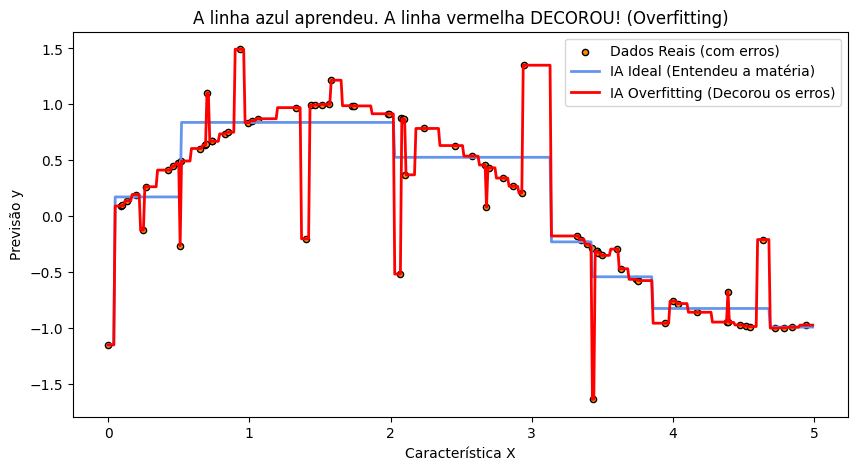

In [ ]:
# Desenhando o gráfico para a turma ver a diferença
X_teste_onda = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
previsao_ideal = modelo_ideal.predict(X_teste_onda)
previsao_decoreba = modelo_decoreba.predict(X_teste_onda)

plt.figure(figsize=(10, 5))
plt.scatter(X_onda, y_onda, s=20, edgecolor="black", c="darkorange", label="Dados Reais (com erros)")
plt.plot(X_teste_onda, previsao_ideal, color="cornflowerblue", label="IA Ideal (Entendeu a matéria)", linewidth=2)
plt.plot(X_teste_onda, previsao_decoreba, color="red", label="IA Overfitting (Decorou os erros)", linewidth=2)
plt.xlabel("Característica X")
plt.ylabel("Previsão y")
plt.title("A linha azul aprendeu. A linha vermelha DECOROU! (Overfitting)")
plt.legend()
plt.show()